In [2]:
# ==========================================
# INSTALL (run this first in Kaggle)
# !pip install albumentations -q
# ==========================================

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import albumentations as A
from albumentations.pytorch import ToTensorV2
from scipy import ndimage
from matplotlib.colors import LinearSegmentedColormap

# ==========================================
# CONFIGURATION — SLOW COMPUTER OPTIMIZED
# ==========================================
CONFIG = {
    "batch_size"  : 8,
    "epochs"      : 20,
    "lr"          : 1e-3,
    "weight_decay": 1e-4,
    "target_size" : (128, 128),
    "num_workers" : 2,
    "seed"        : 42,
    "patience"    : 5,
}

TRAIN_DIR = "/kaggle/input/datasets/shrutinath26/new-new-new-lm/archive (1)/kaggle/working/Cancer"
VAL_DIR   = "/kaggle/input/datasets/shrutinath26/new-new-new-lm/archive (1)/kaggle/working/Val_Cancer"
TEST_DIR  = "/kaggle/input/datasets/shrutinath26/newest-test/content/Testing1"

In [3]:
# STEP 1: SEEDS & DEVICE
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [18]:
# STEP 2: AUGMENTATION PIPELINES 
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussNoise(std_range=(0.02, 0.05), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [7]:
# STEP 3: DATASET & DATALOADERS 
class MedicalDataset(Dataset):
    def __init__(self, base_dir, transform=None, target_size=(128, 128)):
        self.transform   = transform
        self.target_size = target_size
        self.pairs       = []

        # Check standard layout (Direct Image/Mask folders)
        img_dir_standard  = os.path.join(base_dir, "Image")
        mask_dir_standard = os.path.join(base_dir, "Mask")

        if os.path.exists(img_dir_standard) and os.path.exists(mask_dir_standard):
            # Standard Layout Processing (For Train/Val)
            img_files  = {os.path.splitext(f)[0]: os.path.join(img_dir_standard, f) 
                          for f in os.listdir(img_dir_standard) if f.endswith(('.png', '.jpg', '.jpeg'))}
            mask_files = {os.path.splitext(f)[0]: os.path.join(mask_dir_standard, f) 
                          for f in os.listdir(mask_dir_standard) if f.endswith(('.png', '.jpg', '.jpeg'))}
            
            common_keys = sorted(set(img_files.keys()) & set(mask_files.keys()))
            self.pairs = [(img_files[k], mask_files[k]) for k in common_keys]
        
        else:
            # Patient Folders Layout Processing (Updated for 'Images' & 'Mask') 
            subfolders = [os.path.join(base_dir, f) for f in os.listdir(base_dir) 
                          if os.path.isdir(os.path.join(base_dir, f))]
            
            for subfolder in subfolders:
                
                img_sub = os.path.join(subfolder, "Images") 
                mask_sub = os.path.join(subfolder, "Mask")
                
                if os.path.exists(img_sub) and os.path.exists(mask_sub):
                    img_files  = {os.path.splitext(f)[0]: os.path.join(img_sub, f) 
                                  for f in os.listdir(img_sub) if f.endswith(('.png', '.jpg', '.jpeg'))}
                    mask_files = {os.path.splitext(f)[0]: os.path.join(mask_sub, f) 
                                  for f in os.listdir(mask_sub) if f.endswith(('.png', '.jpg', '.jpeg'))}
                    
                    common_keys = sorted(set(img_files.keys()) & set(mask_files.keys()))
                    for k in common_keys:
                        self.pairs.append((img_files[k], mask_files[k]))

        assert len(self.pairs) > 0, f"No matching image-mask pairs found in {base_dir}!"
        print(f"✅ Loaded {len(self.pairs)} matched pairs successfully from {base_dir}")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img  = cv2.imread(img_path,  cv2.IMREAD_COLOR)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img  = cv2.resize(img,  self.target_size)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)

        mask = (mask > 0).astype(np.uint8) 

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask'].unsqueeze(0).float()
        else:
            img  = torch.tensor(np.transpose(img.astype(np.float32)/255., (2,0,1)))
            mask = torch.tensor(mask[None].astype(np.float32))

        return img, mask

# 2. PATHS CONFIGURATION
TRAIN_DIR = "/kaggle/input/datasets/shrutinath26/new-new-new-lm/archive (1)/kaggle/working/Cancer"
VAL_DIR   = "/kaggle/input/datasets/shrutinath26/new-new-new-lm/archive (1)/kaggle/working/Val_Cancer"
TEST_DIR  = "/kaggle/input/datasets/shrutinath26/newest-test/content/Testing1" 

print("⏳ Scanning directories")

# 3. INITIALIZE DATASETS
train_dataset = MedicalDataset(TRAIN_DIR, transform=train_transform, target_size=CONFIG["target_size"])
val_dataset   = MedicalDataset(VAL_DIR,   transform=val_transform,   target_size=CONFIG["target_size"])
test_dataset  = MedicalDataset(TEST_DIR,  transform=val_transform,   target_size=CONFIG["target_size"])

# 4. INITIALIZE DATALOADERS
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

print(f"\n📊 --- FINAL STATUS ---")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

⏳ Scanning directories (Scan chalu hai)...
✅ Loaded 41712 matched pairs successfully from /kaggle/input/datasets/shrutinath26/new-new-new-lm/archive (1)/kaggle/working/Cancer
✅ Loaded 608 matched pairs successfully from /kaggle/input/datasets/shrutinath26/new-new-new-lm/archive (1)/kaggle/working/Val_Cancer
✅ Loaded 3932 matched pairs successfully from /kaggle/input/datasets/shrutinath26/newest-test/content/Testing1

📊 --- FINAL STATUS ---
  Train batches : 5214
  Val batches   : 76
  Test batches  : 492


In [8]:
# STEP 4: U-NET ARCHITECTURE
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.downs  = nn.ModuleList()
        self.ups    = nn.ModuleList()
        self.pool   = nn.MaxPool2d(2)

        ch = in_channels
        for f in features:
            self.downs.append(DoubleConv(ch, f))
            ch = f

        self.bridge = DoubleConv(features[-1], features[-1]*2, dropout=0.3)

        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, stride=2))
            self.ups.append(DoubleConv(f*2, f))

        self.outc = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bridge(x)
        skips.reverse()

        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)
            skip = skips[i//2]
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)

        return self.outc(x)

In [9]:
# STEP 5: LOSS FUNCTIONS
class FocalBceDiceLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce   = nn.functional.binary_cross_entropy_with_logits(logits, targets)
        probs = torch.sigmoid(logits)

        fw    = (self.alpha * (1 - probs)**self.gamma * targets +
                 (1 - self.alpha) * probs**self.gamma * (1 - targets))

        focal = (fw * nn.functional.binary_cross_entropy_with_logits(
                     logits, targets, reduction='none')).mean()

        p    = probs.reshape(-1)
        t    = targets.reshape(-1)
        dice = 1 - (2*(p*t).sum() + 1e-6) / (p.sum() + t.sum() + 1e-6)

        return 0.4*bce + 0.3*focal + 0.3*dice

def dice_coefficient(logits, targets, thr=0.5):
    p = (torch.sigmoid(logits) > thr).float().reshape(-1)
    t = targets.reshape(-1)
    return ((2*(p*t).sum() + 1e-6) / (p.sum() + t.sum() + 1e-6)).item()

# STEP 6: EARLY STOPPING

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')
        self.stop      = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            print(f"  EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True

In [10]:

# STEP 7: TRAINING LOOP

model     = UNet().to(device)
criterion = FocalBceDiceLoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

def lr_lambda(epoch):
    warmup = 3
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / (CONFIG["epochs"] - warmup)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler  = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler     = torch.amp.GradScaler(device_type)
early_stop = EarlyStopping(patience=CONFIG["patience"])

history       = {'train_loss':[], 'val_loss':[], 'train_dice':[], 'val_dice':[]}
best_val_loss = float('inf')

print(f"\n🚀 Training | Batch={CONFIG['batch_size']} | Size={CONFIG['target_size']} | Epochs={CONFIG['epochs']}")

for epoch in range(CONFIG["epochs"]):
    # ---- TRAIN ----
    model.train()
    t_loss = t_dice = 0.0

    for i, (imgs, masks) in enumerate(train_loader):
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type):
            out  = model(imgs)
            loss = criterion(out, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        t_loss += loss.item()
        t_dice += dice_coefficient(out, masks)

        if i % 100 == 0:
            print(f"  Epoch {epoch+1} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}", end="\r")

    scheduler.step()

    # VALIDATE 
    model.eval()
    v_loss = v_dice = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            with torch.amp.autocast(device_type):
                out  = model(imgs)
                loss = criterion(out, masks)

            v_loss += loss.item()
            v_dice += dice_coefficient(out, masks)

    t_loss /= len(train_loader);  t_dice /= len(train_loader)
    v_loss /= len(val_loader);    v_dice /= len(val_loader)

    history['train_loss'].append(t_loss);  history['val_loss'].append(v_loss)
    history['train_dice'].append(t_dice);  history['val_dice'].append(v_dice)

    lr_now = optimizer.param_groups[0]['lr']
    print(f"\n✨ Epoch {epoch+1:>2}/{CONFIG['epochs']} | "
          f"Train Loss: {t_loss:.4f} Dice: {t_dice:.4f} | "
          f"Val Loss: {v_loss:.4f} Dice: {v_dice:.4f} | LR: {lr_now:.6f}")

    early_stop(v_loss)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), 'best_unet_model.pth')
        print("  🥇 Best model saved → best_unet_model.pth")

    if early_stop.stop:
        print("⛔ Early stopping triggered!")
        break


🚀 Training | Batch=8 | Size=(128, 128) | Epochs=20
  Epoch 1 | Batch 5200/5214 | Loss: 0.2483
✨ Epoch  1/20 | Train Loss: 0.1999 Dice: 0.4447 | Val Loss: 0.1158 Dice: 0.6663 | LR: 0.000667
  🥇 Best model saved → best_unet_model.pth
  Epoch 2 | Batch 5200/5214 | Loss: 0.0801
✨ Epoch  2/20 | Train Loss: 0.1380 Dice: 0.5865 | Val Loss: 0.1129 Dice: 0.6690 | LR: 0.001000
  🥇 Best model saved → best_unet_model.pth
  Epoch 3 | Batch 5200/5214 | Loss: 0.0641
✨ Epoch  3/20 | Train Loss: 0.1316 Dice: 0.6052 | Val Loss: 0.1060 Dice: 0.6917 | LR: 0.001000
  🥇 Best model saved → best_unet_model.pth
  Epoch 4 | Batch 5200/5214 | Loss: 0.2564
✨ Epoch  4/20 | Train Loss: 0.1253 Dice: 0.6239 | Val Loss: 0.1065 Dice: 0.6911 | LR: 0.000991
  EarlyStopping: 1/5
  Epoch 5 | Batch 5200/5214 | Loss: 0.0682
✨ Epoch  5/20 | Train Loss: 0.1204 Dice: 0.6379 | Val Loss: 0.1023 Dice: 0.7118 | LR: 0.000966
  🥇 Best model saved → best_unet_model.pth
  Epoch 6 | Batch 5200/5214 | Loss: 0.0798
✨ Epoch  6/20 | Train 

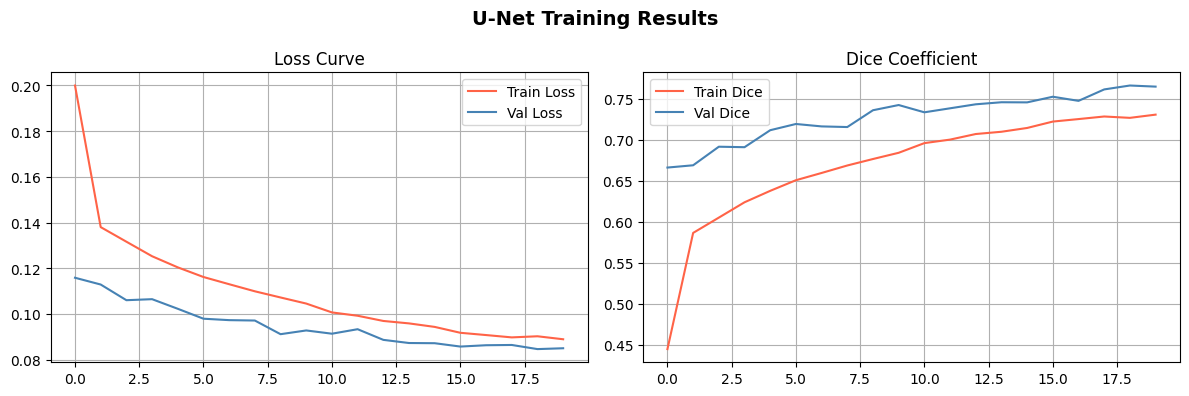

In [11]:
# STEP 8: LOSS CURVES
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("U-Net Training Results", fontsize=14, fontweight='bold')

axes[0].plot(history['train_loss'], label='Train Loss', color='tomato')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='steelblue')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history['train_dice'], label='Train Dice', color='tomato')
axes[1].plot(history['val_dice'],   label='Val Dice',   color='steelblue')
axes[1].set_title('Dice Coefficient'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [15]:
# STEP 9: DETAILED SEGMENTATION TESTING UTILS
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = np.transpose(tensor.numpy(), (1,2,0))
    return np.clip(img * std + mean, 0, 1)

def compute_all_metrics(logits, mask_t):
    prob     = torch.sigmoid(logits).squeeze().cpu().numpy()
    pred_bin = (prob > 0.5).astype(np.float32)
    true     = mask_t.squeeze().numpy()

    intersection = (pred_bin * true).sum()
    dice = (2 * intersection + 1e-6) / (pred_bin.sum() + true.sum() + 1e-6)
    iou  = (intersection + 1e-6) / (pred_bin.sum() + true.sum() - intersection + 1e-6)

    tp = (pred_bin * true).sum()
    fn = ((1 - pred_bin) * true).sum()
    fp = (pred_bin * (1 - true)).sum()
    sensitivity = (tp + 1e-6) / (tp + fn + 1e-6)
    precision   = (tp + 1e-6) / (tp + fp + 1e-6)

    return {
        'dice': dice, 'iou': iou,
        'sensitivity': sensitivity, 'precision': precision,
        'prob': prob, 'pred_bin': pred_bin, 'true': true
    }

heat_cmap = LinearSegmentedColormap.from_list('heat', ['#000033','#0000FF','#00FFFF','#FFFF00','#FF0000'], N=256)

def plot_grid(indices, title, filename, dataset_obj):
    n = len(indices)
    fig, axes = plt.subplots(n, 5, figsize=(20, 4*n))
    fig.suptitle(title, fontsize=15, fontweight='bold')

    if n == 1:
        axes = [axes]

    for row, idx in enumerate(indices):
        img_t, mask_t = dataset_obj[idx]
        with torch.no_grad():
            with torch.amp.autocast(device_type):
                logits = best_model(img_t.unsqueeze(0).to(device))
        m    = compute_all_metrics(logits.cpu(), mask_t)
        orig = denormalize(img_t)

        # Col 0: Original Image
        axes[row][0].imshow(orig)
        axes[row][0].set_title(f"Sample {idx}\nOriginal Scan", fontsize=9)
        axes[row][0].axis('off')

        # Col 1: True Mask
        axes[row][1].imshow(m['true'], cmap='gray')
        axes[row][1].set_title("True Mask\n(Ground Truth)", fontsize=9)
        axes[row][1].axis('off')

        # Col 2: Predicted Mask
        axes[row][2].imshow(m['pred_bin'], cmap='gray')
        axes[row][2].set_title(f"Predicted Mask\nDice:{m['dice']:.3f} IoU:{m['iou']:.3f}", fontsize=9)
        axes[row][2].axis('off')

        # Col 3: Confidence Heatmap
        hm = axes[row][3].imshow(m['prob'], cmap=heat_cmap, vmin=0, vmax=1)
        axes[row][3].set_title(f"Confidence Map\nSens:{m['sensitivity']:.3f} Prec:{m['precision']:.3f}", fontsize=9)
        axes[row][3].axis('off')
        plt.colorbar(hm, ax=axes[row][3], fraction=0.046, pad=0.04)

        # Col 4: Overlay Boundary Detection
        overlay = orig.copy()
        overlay[:,:,0] = np.clip(overlay[:,:,0] + m['pred_bin'] * 0.4, 0, 1)
        overlay[:,:,1] = np.clip(overlay[:,:,1] - m['pred_bin'] * 0.2, 0, 1)
        overlay[:,:,2] = np.clip(overlay[:,:,2] - m['pred_bin'] * 0.2, 0, 1)

        from scipy import ndimage
        dilated  = ndimage.binary_dilation(m['true'].astype(bool),  iterations=2)
        eroded   = ndimage.binary_erosion(m['true'].astype(bool),   iterations=2)
        boundary = np.clip(dilated.astype(float) - eroded.astype(float), 0, 1)
        overlay[:,:,1] = np.clip(overlay[:,:,1] + boundary * 0.8, 0, 1)
        overlay[:,:,0] = np.clip(overlay[:,:,0] - boundary * 0.3, 0, 1)

        axes[row][4].imshow(overlay)
        axes[row][4].set_title("Overlay\n🔴Pred  🟢True boundary", fontsize=9)
        axes[row][4].axis('off')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Saved: {filename}")

In [17]:

# STEP 10: TEST DATASET EVALUATION (SCORES PRINT)
print("🧪 Evaluating Best Model on Test Dataset (Testing1)...")

best_model.eval()  # Model ko evaluation mode mein set kiya

total_dice = 0.0
total_iou = 0.0
total_samples = 0

# Gradients calculate karne ki zaroorat nahi hai testing mein
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        
        # Mixed precision loop (agar training mein use kiya tha toh)
        with torch.amp.autocast(device_type):
            logits = best_model(images)
            
        # Raw outputs ko probabilities mein convert karo
        probs = torch.sigmoid(logits)
        preds_bin = (probs > 0.5).float() # Threshold lagakar 0 ya 1 kiya
        
        masks = masks.to(device)
        
        # Batch ke har sample ke liye Dice aur IoU nikalo
        for i in range(images.size(0)):
            p = preds_bin[i].squeeze()
            t = masks[i].squeeze()
            
            intersection = (p * t).sum().item()
            p_sum = p.sum().item()
            t_sum = t.sum().item()
            
            # Mathematical formulas for Dice and IoU
            dice = (2.0 * intersection + 1e-6) / (p_sum + t_sum + 1e-6)
            iou = (intersection + 1e-6) / (p_sum + t_sum - intersection + 1e-6)
            
            total_dice += dice
            total_iou += iou
            total_samples += 1

# Average Scores calculate karein
avg_dice = total_dice / total_samples
avg_iou = total_iou / total_samples


print(f"🏆 FINAL TEST SET PERFORMANCE (Total Images: {total_samples})")

print(f"🎯 Average Dice Coefficient : {avg_dice:.4f}  ({avg_dice*100:.2f}%)")
print(f"📐 Average IoU (Jaccard)    : {avg_iou:.4f}  ({avg_iou*100:.2f}%)")


🧪 Evaluating Best Model on Test Dataset (Testing1)...
🏆 FINAL TEST SET PERFORMANCE (Total Images: 3932)
🎯 Average Dice Coefficient : 0.7832  (78.32%)
📐 Average IoU (Jaccard)    : 0.7366  (73.66%)



📊 Running final testing loop on UNSEEN TEST DATASET (3932 samples)...

  🔥 ACTUAL TEST DATASET RESULTS 🔥
  Test Dice Score : 0.7832 ± 0.3327
  Test IoU Score  : 0.7366  ± 0.3453
  Best Test Dice  : 1.0000
  Worst Test Dice : 0.0000

🎲 Plotting test random samples...


/tmp/ipykernel_58/2277721883.py:88: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/2277721883.py:88: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/2277721883.py:89: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=150, bbox_inches='tight')
/tmp/ipykernel_58/2277721883.py:89: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, dpi=150, bbox_inches='tight')


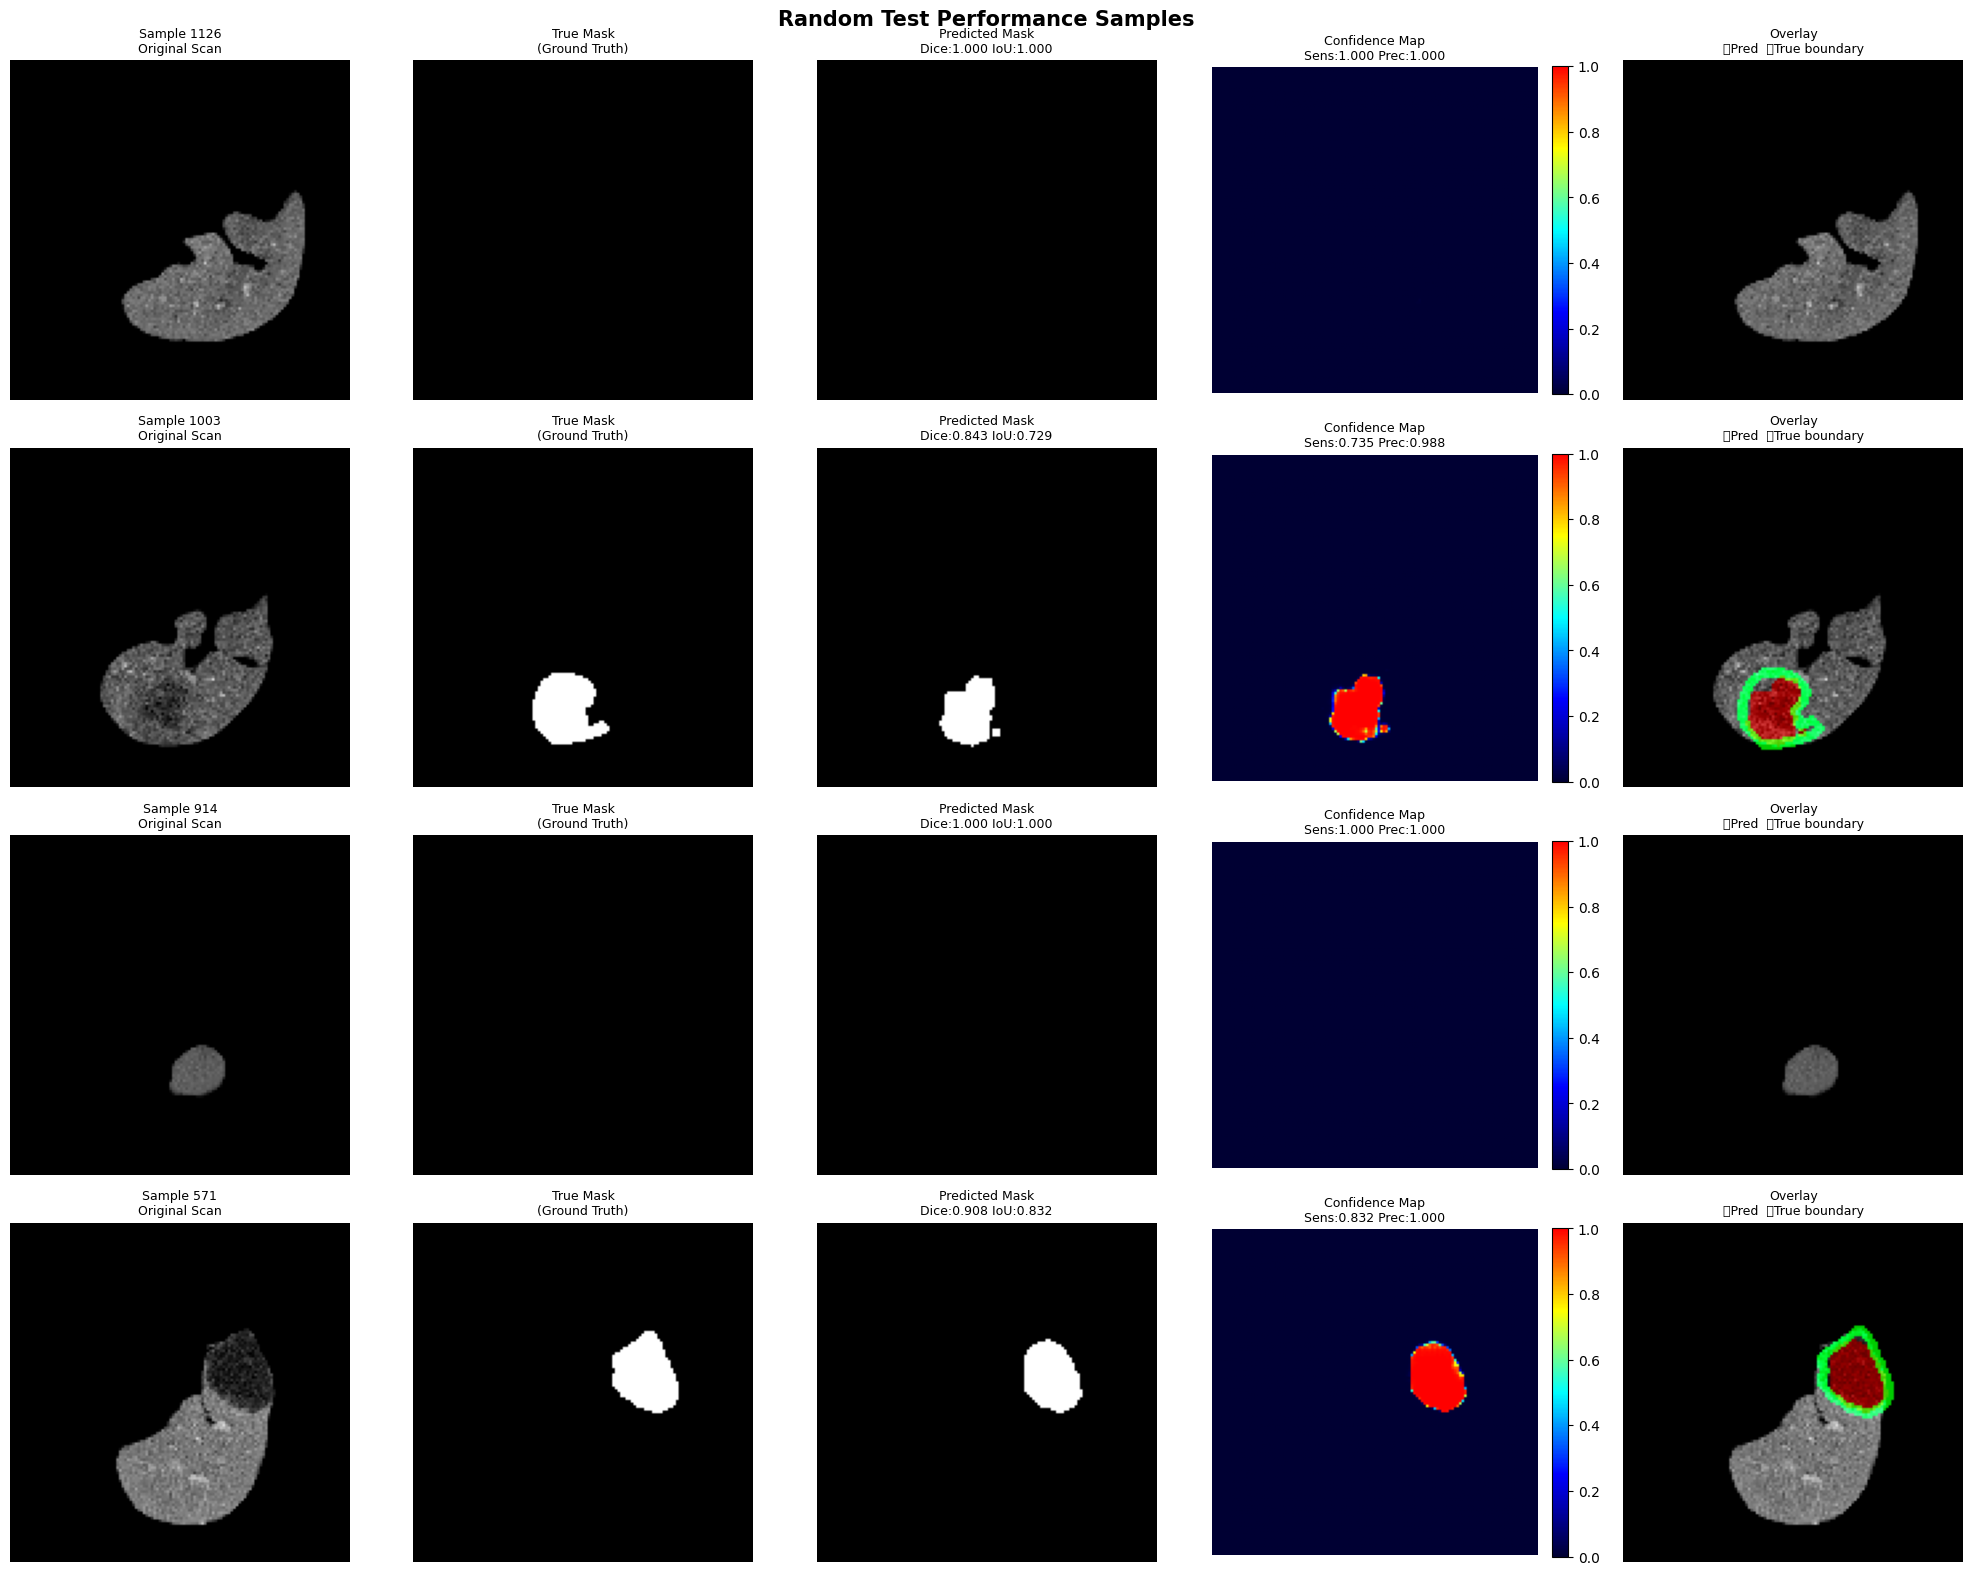

  ✅ Saved: test_random.png

🏆 Plotting test best predictions...


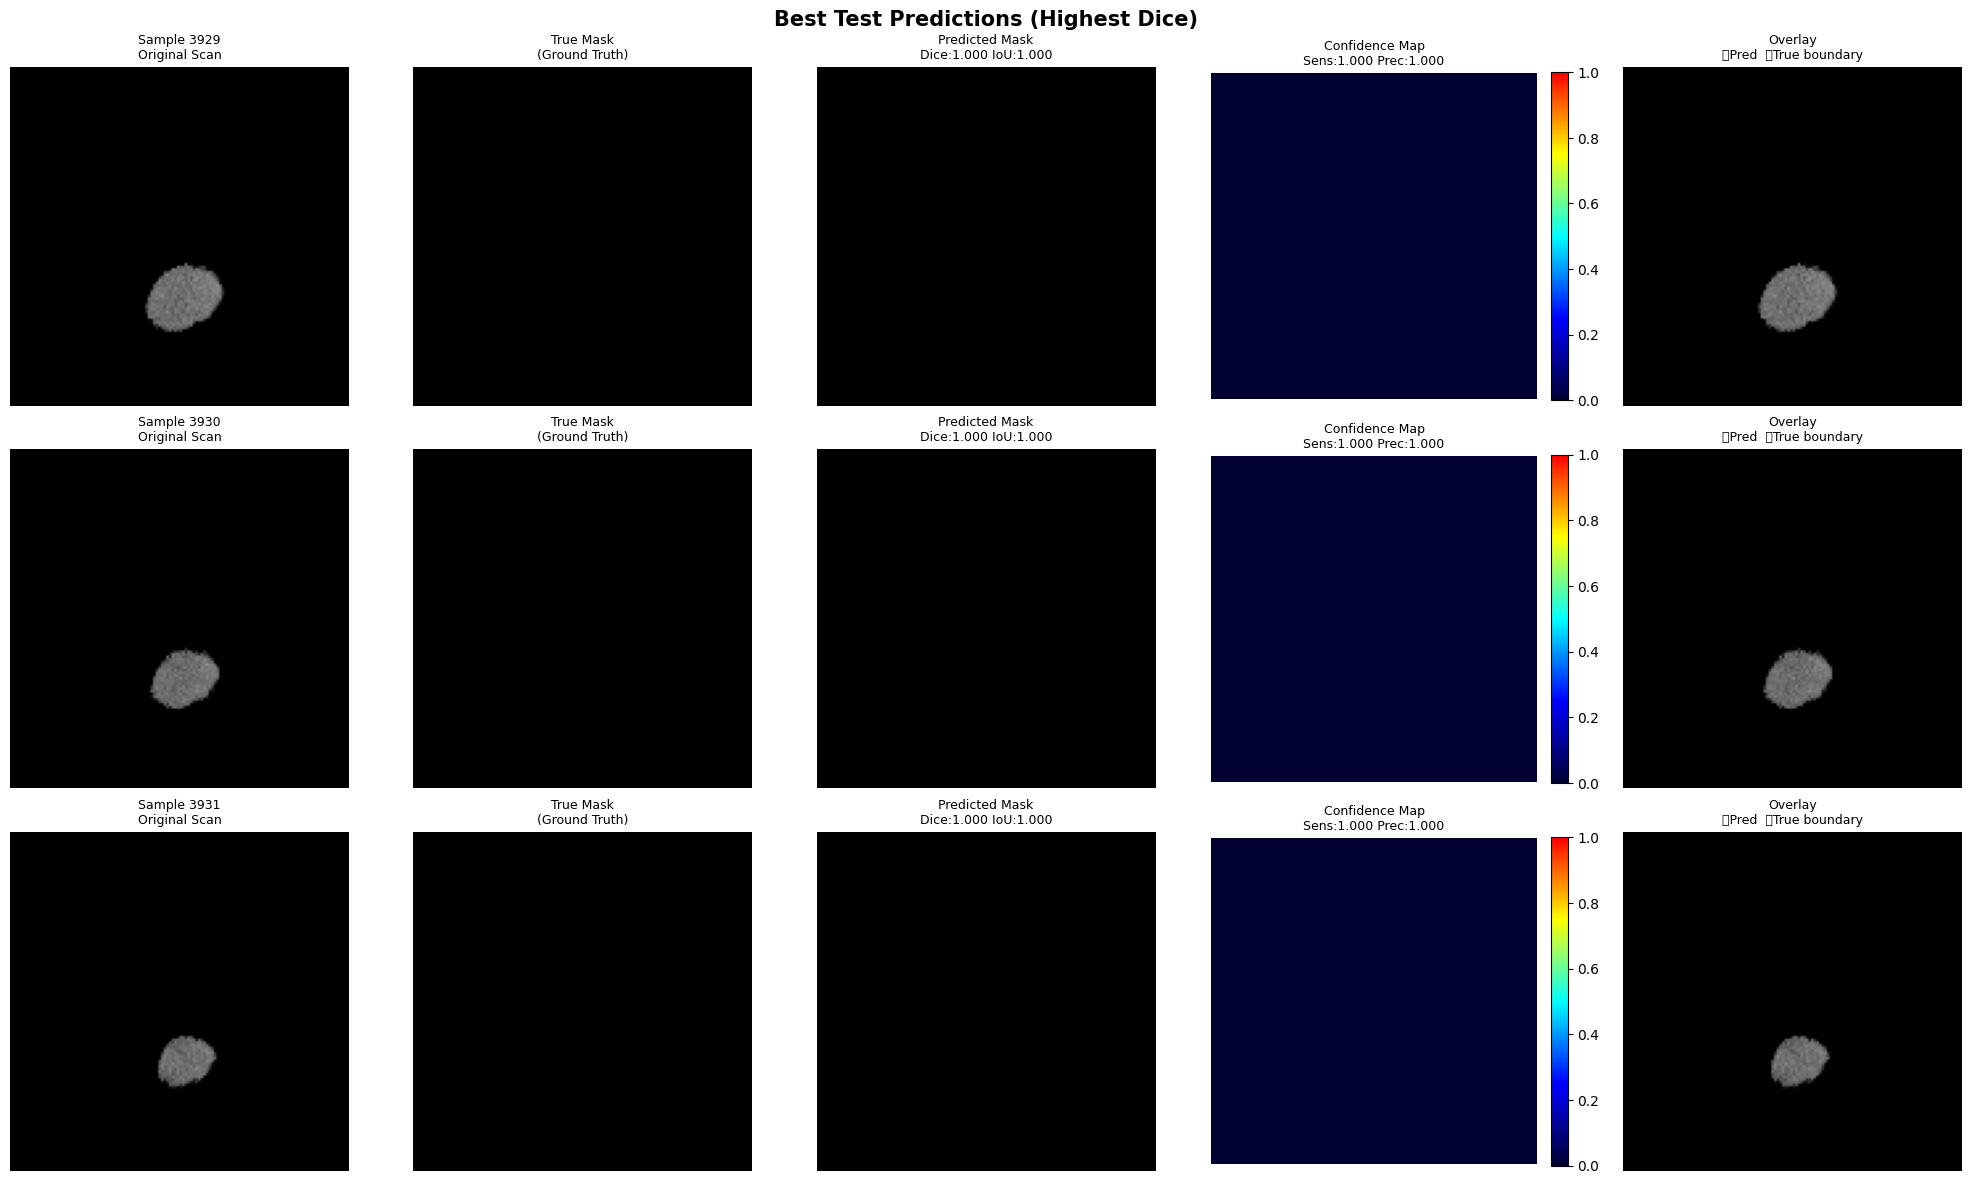

  ✅ Saved: test_best.png

⚠️ Plotting test worst predictions...


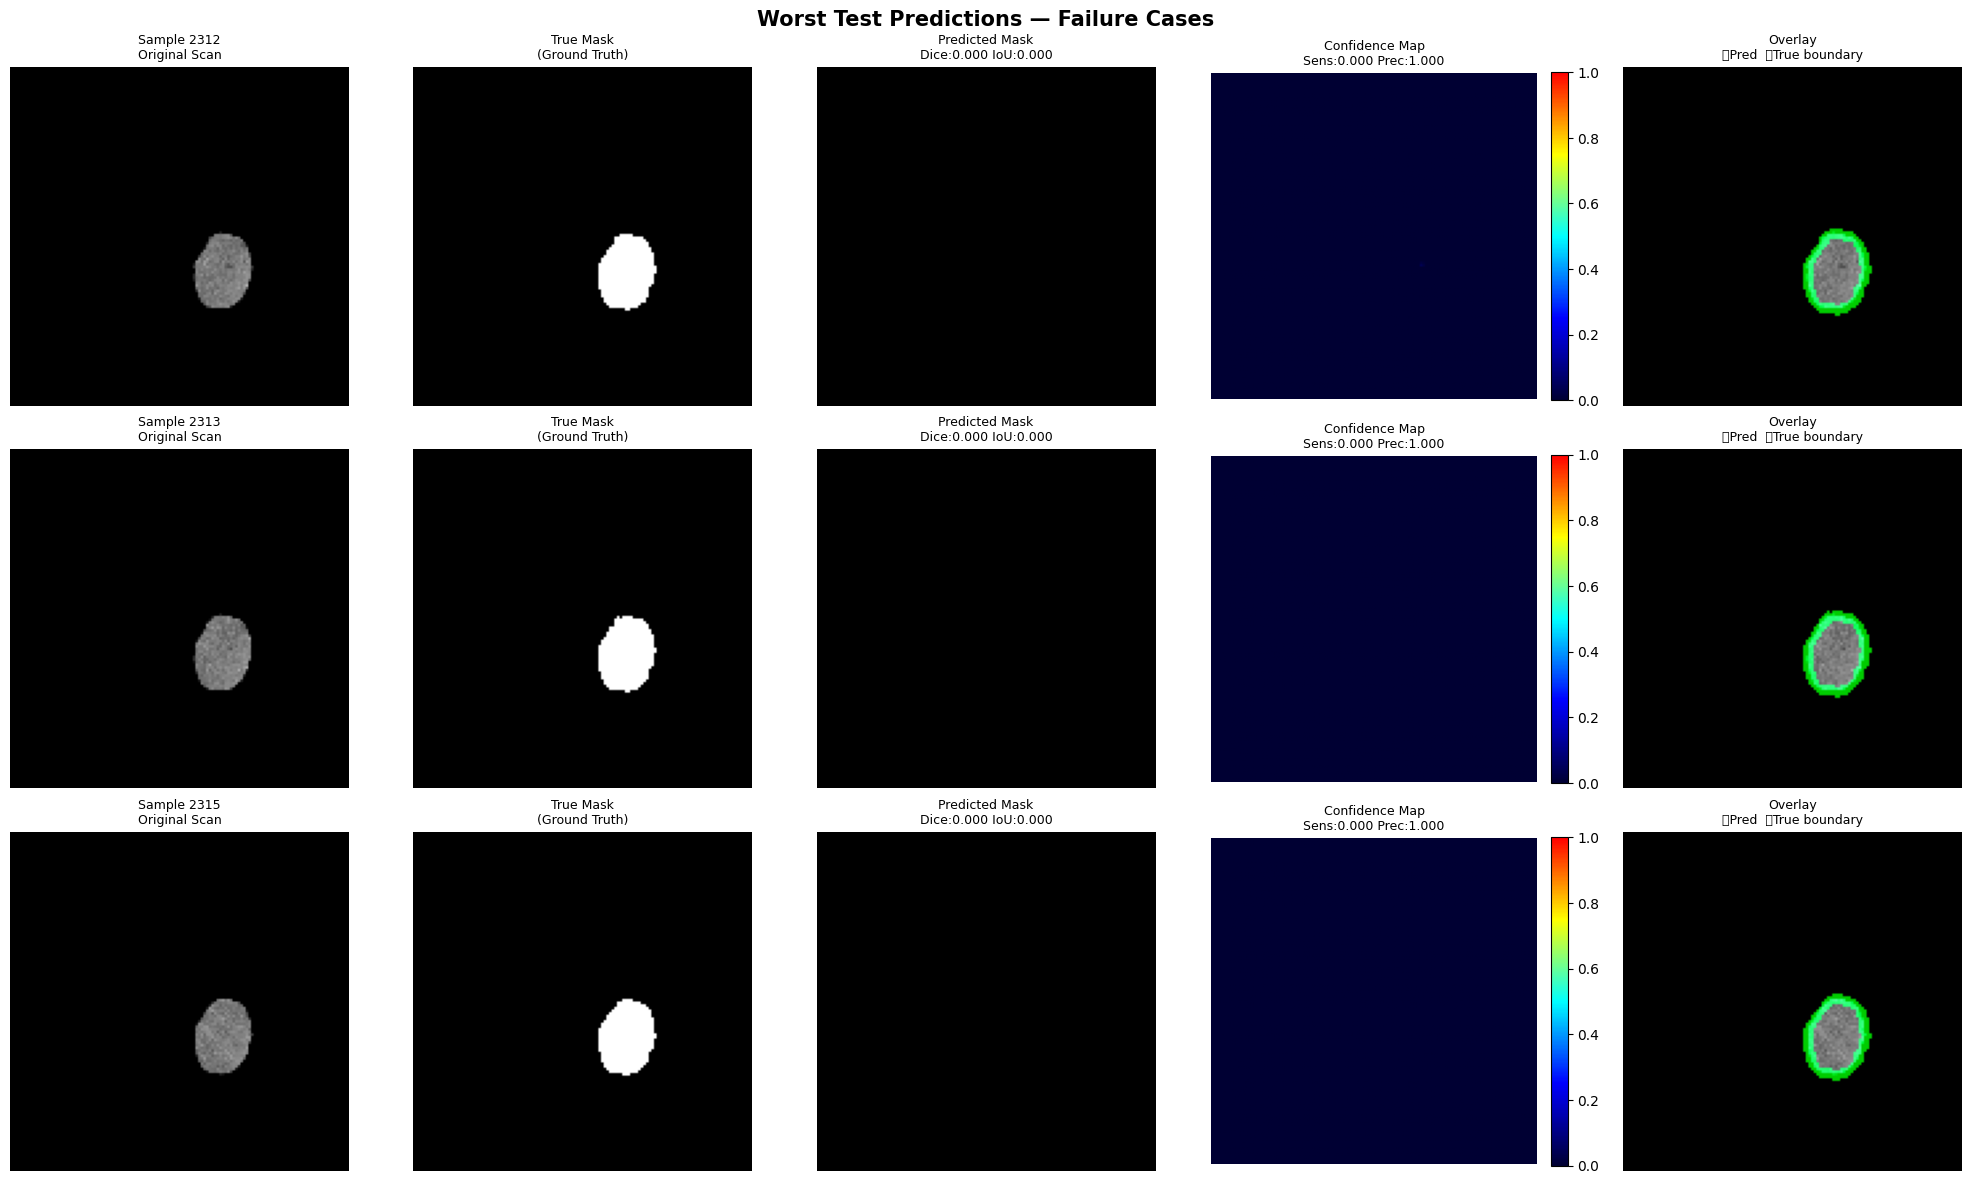

  ✅ Saved: test_worst.png


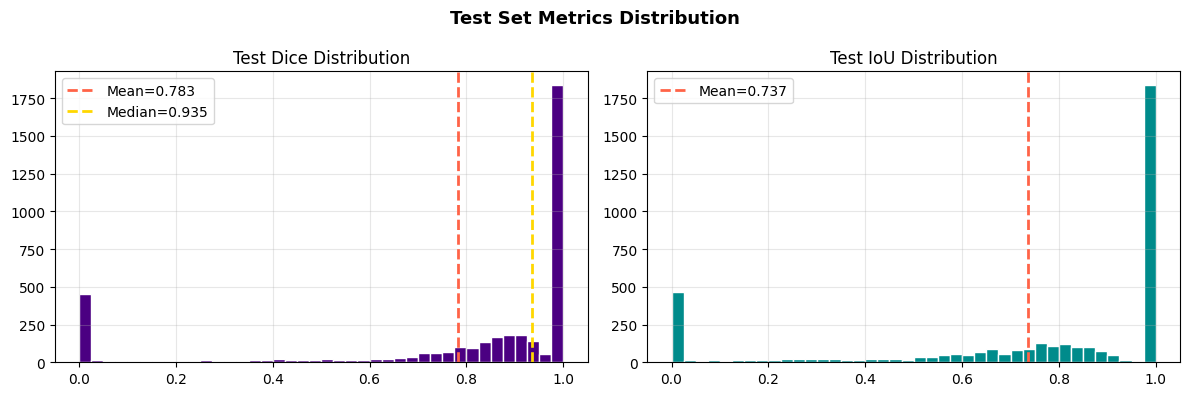


✅ Execution finished. Subplots generated on genuine unseen data structure!


In [14]:
# ==========================================
# STEP 10: ACTUAL UNSEEN TEST EVALUATION 
# ==========================================
# ✅ Yeh direct aapke naye 'test_dataset' variable ko hi point karega!
target_eval_dataset = test_dataset  

print(f"\n📊 Running final testing loop on UNSEEN TEST DATASET ({len(target_eval_dataset)} samples)...")

best_model = UNet().to(device)
best_model.load_state_dict(torch.load('best_unet_model.pth', map_location=device))
best_model.eval()

all_scores = []
all_dice = []
all_iou  = []

with torch.no_grad():
    for idx in range(len(target_eval_dataset)):
        img_t, mask_t = target_eval_dataset[idx]
        with torch.amp.autocast(device_type):
            logits = best_model(img_t.unsqueeze(0).to(device))
            
        m = compute_all_metrics(logits.cpu(), mask_t)
        all_scores.append((idx, m['dice'], m['iou']))
        all_dice.append(m['dice'])
        all_iou.append(m['iou'])

# Performance sorting logic to catch edge cases
all_scores.sort(key=lambda x: x[1])
worst_idx  = [x[0] for x in all_scores[:3]]
best_idx   = [x[0] for x in all_scores[-3:]]
random_idx = random.sample(range(len(target_eval_dataset)), 4)

print(f"\n{'='*50}")
print(f"  🔥 ACTUAL TEST DATASET RESULTS 🔥")
print(f"{'='*50}")
print(f"  Test Dice Score : {np.mean(all_dice):.4f} ± {np.std(all_dice):.4f}")
print(f"  Test IoU Score  : {np.mean(all_iou):.4f}  ± {np.std(all_iou):.4f}")
print(f"  Best Test Dice  : {np.max(all_dice):.4f}")
print(f"  Worst Test Dice : {np.min(all_dice):.4f}")
print(f"{'='*50}")

# Plotting grids using updated test dataset references
print("\n🎲 Plotting test random samples...")
plot_grid(random_idx, "Random Test Performance Samples", "test_random.png", target_eval_dataset)

print("\n🏆 Plotting test best predictions...")
plot_grid(best_idx, "Best Test Predictions (Highest Dice)", "test_best.png", target_eval_dataset)

print("\n⚠️ Plotting test worst predictions...")
plot_grid(worst_idx, "Worst Test Predictions — Failure Cases", "test_worst.png", target_eval_dataset)

# Final score distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Test Set Metrics Distribution", fontsize=13, fontweight='bold')

axes[0].hist(all_dice, bins=40, color='indigo', edgecolor='white')
axes[0].axvline(np.mean(all_dice), color='tomato',  linestyle='--', linewidth=2, label=f'Mean={np.mean(all_dice):.3f}')
axes[0].axvline(np.median(all_dice), color='gold', linestyle='--', linewidth=2, label=f'Median={np.median(all_dice):.3f}')
axes[0].set_title('Test Dice Distribution')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(all_iou, bins=40, color='darkcyan', edgecolor='white')
axes[1].axvline(np.mean(all_iou), color='tomato', linestyle='--', linewidth=2, label=f'Mean={np.mean(all_iou):.3f}')
axes[1].set_title('Test IoU Distribution')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150)
plt.show()

print("\n✅ Execution finished. Subplots generated on genuine unseen data structure!")